# Анализ эффективности рекламной кампании: А/В-тестирование и продуктовые инсайты

### Описание проекта
В данном проекте проводится комплексный анализ результатов А/В-тестирования новой рекламной кампании. На основе исторических данных о поведении пользователей нам необходимо определить, эффективна ли новая реклама, оптимизировать частоту показов и выявить скрытые паттерны для медиапланирования.

### Цели исследования:
1. **Валидация данных:** Проверить корректность разделения пользователей на группы (отсутствие пересечений).
2. **Статистический анализ:** Оценить статистическую значимость изменений в конверсии с помощью Z-теста для пропорций.
3. **Продуктовый анализ:** Рассчитать относительный прирост (Relative Lift) и доверительные интервалы для разницы долей.
4. **Оптимизация бюджета:** Найти точку насыщения рекламой (Frequency Capping).
5. **Временной анализ:** Выявить лучшие дни недели для открутки рекламных бюджетов.

---
## Шаг 1. Загрузка данных и первичный аудит (Data Quality Check)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('marketing_AB.csv', sep=',')

In [5]:
df = df.drop(columns=['Unnamed: 0'])

In [11]:
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [14]:
len(df)

588101

In [15]:
df['user id'].nunique()

588101

In [21]:
ad_users = set(df[df['test group'] == 'ad']['user id'])
psa_users = set(df[df['test group'] == 'psa']['user id'])
overlap = ad_users.intersection(psa_users)
len(overlap)

0

## Шаг 2. Расчет базовых метрик и группировка А/В-теста

Для верхнеуровневого понимания эксперимента сгруппируем данные по тестовым группам. Мы используем метод **именованной агрегации (Named Aggregation)** в Pandas, чтобы сразу получить чистую таблицу с тремя метриками:
* `count_converted` — общее количество пользователей в группе.
* `sum_converted` — абсолютное число покупателей (успехов).
* `mean_converted` — базовая конверсия в покупку (доля успехов).

*Группы в эксперименте:*
* `ad` — тестовая группа (пользователи, видевшие новую рекламу).
* `psa` — контрольная группа (пользователи, видевшие стандартное социальное объявление платформы).

In [24]:
conversion_rate = df.groupby('test group').agg(
    count_converted=('converted', 'count'),
    sum_converted=('converted', 'sum'),
    mean_converted=('converted', 'mean')
).reset_index()

print(conversion_rate)

  test group  count_converted  sum_converted  mean_converted
0         ad           564577          14423        0.025547
1        psa            23524            420        0.017854


## Шаг 3. Проверка статистической значимости (Z-тест для пропорций)

Визуально конверсия в тестовой группе выше, однако в аналитике данных необходимо доказать, что этот прирост не является случайным шумом.

### Формулирование гипотез:
* **Нулевая гипотеза ($H_0$):** Разницы в конверсии между группами `ad` и `psa` нет. Эффект от рекламы равен нулю.
* **Альтернативная гипотеза ($H_1$):** Разница в конверсии реальна. Реклама значимо влияет на метрику.

Для проверки используем **двусторонний Z-тест для пропорций** (стандарт для бинарных метрик на больших выборках) с порогом значимости $\alpha = 0.05$.

In [26]:
successes = conversion_rate['sum_converted'].tolist()
nobs = conversion_rate['count_converted'].tolist()

print(successes)
print(nobs)

[14423, 420]
[564577, 23524]


In [28]:
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(successes, nobs, alternative='two-sided')

print(z_stat)
print(p_value)

7.3700781265454145
1.7052807161559727e-13


## Шаг 4. Оценка практической значимости и доверительных интервалов

Статистическая значимость доказана ($p\text{-value} < 0.05$). Переходим к оценке **практической (бизнес) значимости** эффекта. Нам необходимо рассчитать:
1. **Relative Lift (Относительный прирост)** — на сколько процентов конверсия в тесте выше контроля.
2. **95%-й доверительный интервал (Confidence Interval)** для разницы долей методом Уолда (`wald`), чтобы определить границы истинного эффекта при раскатке на всю аудиторию.

In [32]:
cr_ad = conversion_rate.loc[conversion_rate['test group'] == 'ad',
    'mean_converted'].values[0]
cr_psa = conversion_rate.loc[conversion_rate['test group'] == 'psa',
    'mean_converted'].values[0]

relative_lift = round((cr_ad - cr_psa) / cr_psa * 100, 2)
print(relative_lift)

43.09


In [35]:
from statsmodels.stats.proportion import confint_proportions_2indep

lower, upper = confint_proportions_2indep(successes[0], nobs[0], successes[1], nobs[1], method='wald', alpha=0.05)

lower_percent = round(lower * 100, 2)
upper_percent = round(upper * 100, 2)

print(lower_percent, upper_percent)

0.6 0.94


## Шаг 5. Продуктовый глубокий анализ: Частота показов (Frequency Analysis)

Показ рекламы платный, поэтому бизнесу критически важно определить оптимальное число показов на одного пользователя (**Frequency Capping**). Избыточные показы выжигают аудиторию и сливают бюджет.

Исследуем распределение метрики `total ads` (количество увиденных объявлений) для покупателей и непокупателей, а также разобьем непрерывную величину на категориальные корзины (интервалы) с помощью `pd.cut()`.

In [38]:
df[df['converted'] == False]['total ads'].describe()

count    573258.000000
mean         23.291495
std          40.863176
min           1.000000
25%           4.000000
50%          13.000000
75%          26.000000
max        2065.000000
Name: total ads, dtype: float64

In [42]:
df[df['converted'] == True]['total ads'].describe()

count    14843.000000
mean        83.887759
std         87.455498
min          1.000000
25%         35.000000
50%         64.000000
75%        103.000000
max       1778.000000
Name: total ads, dtype: float64

In [43]:
bins = [0, 5, 10, 20, 50, 100, float('inf')]
labels = ['1-5', '6-10', '11-20', '21-50', '51-100', '100+']

In [44]:
df['ads_group'] = pd.cut(df['total ads'], bins=bins, labels=labels)

In [46]:
frequency_capping = df.groupby('ads_group', observed = False).agg(
    count_frequency = ('converted', 'count'),
    mean_frequency = ('converted', 'mean')
).reset_index()

In [47]:
print(frequency_capping)

  ads_group  count_frequency  mean_frequency
0       1-5           177823        0.002525
1      6-10            82952        0.004931
2     11-20           127484        0.008393
3     21-50           130776        0.028859
4    51-100            46002        0.113952
5      100+            23064        0.169051


### Визуализация зависимости конверсии от частоты показов
Построим столбчатую диаграмму, чтобы наглядно увидеть, как меняется конверсия при переходе пользователя из одной частотной группы в другую.

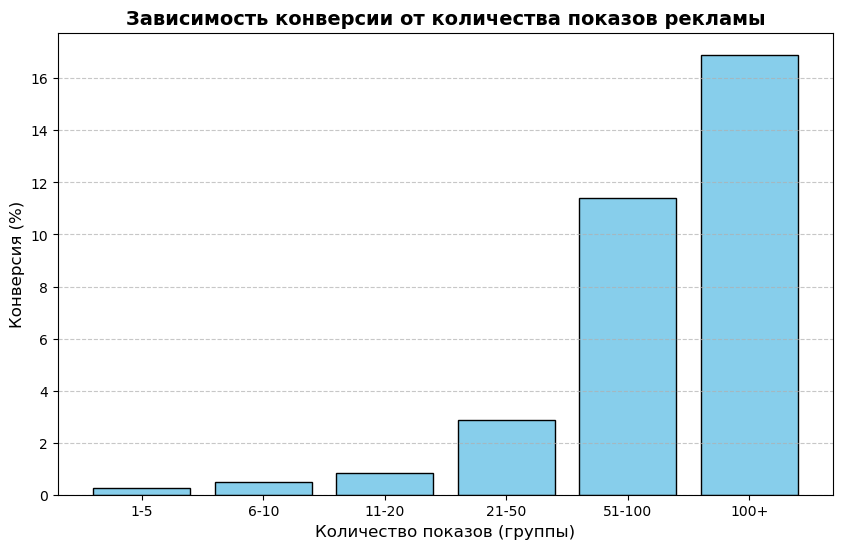

In [50]:
# Создаем график
plt.figure(figsize=(10,6))

# Рисуем столбцы: по оси X - группы показов, по оси Y - конверсия в процентах
plt.bar(frequency_capping['ads_group'], frequency_capping['mean_frequency'] * 100, color = 'skyblue', edgecolor='black')

# Добавляем подписи и заголовки
plt.title('Зависимость конверсии от количества показов рекламы', fontsize=14, fontweight='bold')
plt.xlabel('Количество показов (группы)', fontsize=12)
plt.ylabel('Конверсия (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # добавляем сетку

plt.show()


## Шаг 6. Анализ временных паттернов (Эффективность по дням недели)

Изучим столбец `most ads day` (день пиковой открутки рекламы). Чтобы избежать хаотичной алфавитной сортировки дней недели в Pandas, переведем этот столбец в упорядоченный категориальный тип данных (`CategoricalDtype`). Это позволит построить корректный хронологический таймлайн от понедельника до воскресенья.

In [52]:
# 1. Задаем правильный хронологический порядок дней
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 2. Перезаписываем столбец в исходном df, делая его упорядоченным категориальным типом
df['most ads day'] = pd.Categorical(df['most ads day'], categories=days_order, ordered=True)

days_analysis = df.groupby('most ads day', observed=False).agg(
    total_users = ('converted', 'count'),
    conversion_rate = ('converted', 'mean')
).reset_index()

print(days_analysis)

  most ads day  total_users  conversion_rate
0       Monday        87073         0.032812
1      Tuesday        77479         0.029840
2    Wednesday        80908         0.024942
3     Thursday        82982         0.021571
4       Friday        92608         0.022212
5     Saturday        81660         0.021051
6       Sunday        85391         0.024476


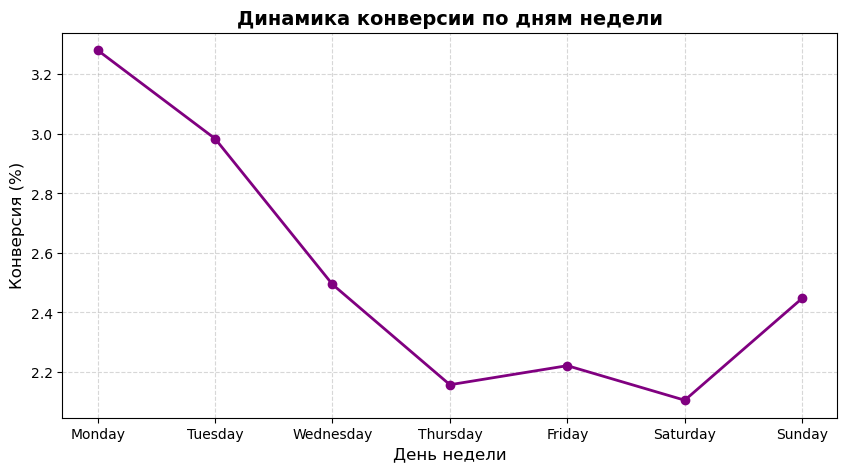

In [54]:
# 4. Строим линейный график для конверсии
plt.figure(figsize=(10, 5))
plt.plot(days_analysis['most ads day'], days_analysis['conversion_rate'] * 100, marker='o', color='purple', linewidth=2)

# Оформление
plt.title('Динамика конверсии по дням недели', fontsize=14, fontweight='bold')
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Конверсия (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

## 🏁 Итоговое заключение (Executive Summary)

### 1. Результаты А/В-теста
* Тестовая группа (`ad`) показала конверсию **2.55%**, контрольная (`psa`) — **1.79%**.
* **Относительный прирост составляет 43.09%**.
* Разница математически доказана: Z-тест выдал $p\text{-value} \approx 1.7 \times 10^{-13}$, что значительно ниже порога 0.05.
* 95%-й доверительный интервал равен **[0.60%, 0.94%]** и полностью лежит в положительной зоне. 
* **Рекомендация:** Эксперимент успешен. Рекомендуется раскатать новую рекламную кампанию на всю аудиторию.

### 2. Оптимизация частоты показов (Экономия бюджета)
* В данных обнаружен сильный правый скос: медиана показов для покупателей составляет 64, при этом зафиксированы аномальные выбросы (более 2000 показов на пользователя без покупки).
* Взрывной рост конверсии на высоких частотах (51-100 и 100+ показов) обусловлен **обратной причинностью**: лояльные пользователи проводят много времени на платформе, поэтому алгоритм успевает показать им больше рекламы. Бесконечный повтор объявлений холодным юзерам неэффективен.
* **Рекомендация:** Настроить лимит показов (**Frequency Cap**) на уровне 20-30 объявлений на уникального пользователя за кампанию для оптимизации затрат.

### 3. Рекомендации по медиапланированию
* Понедельник (3.28%) и вторник (2.98%) — дни с наивысшей конверсией.
* Пятница — день с максимальным объемом трафика (92.6 тыс. пользователей), но низкой конверсией (2.22%). Суббота — абсолютный минимум эффективности (2.11%).
* **Рекомендация:** Перераспределить рекламный бюджет, снизив интенсивность показов в неэффективные выходные дни (пятница, суббота) и усилив присутствие в начале недели (понедельник, вторник).